In [1]:
import matplotlib.pyplot as plt
from datetime import datetime


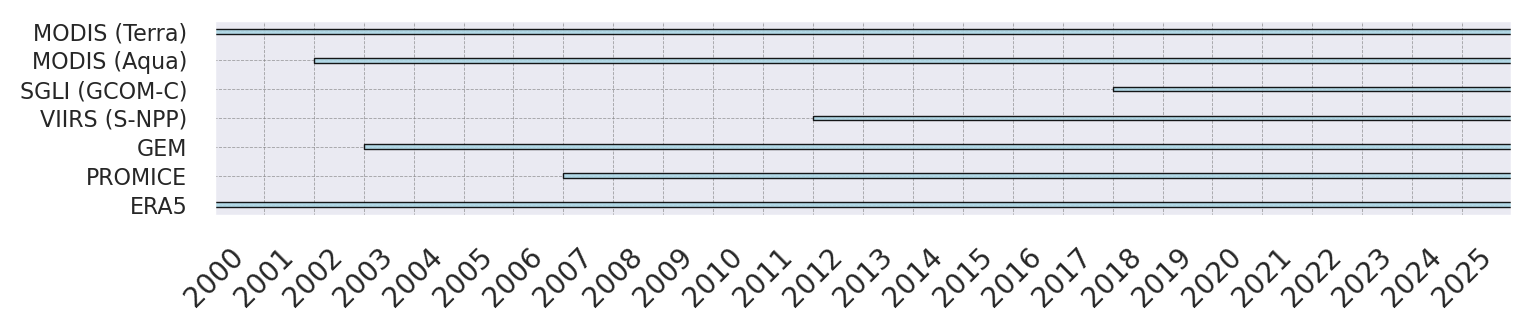

In [56]:

satellites = {
    "MODIS (Terra)": (datetime(2000, 2, 24), datetime(2025, 12, 31)),
    "MODIS (Aqua)": (datetime(2002, 7, 4), datetime(2025, 12, 31)),
    "SGLI (GCOM-C)": (datetime(2018, 1, 1), datetime(2025, 12, 31)),
    "VIIRS (S-NPP)": (datetime(2012, 1, 19), datetime(2025, 12, 31)),
    "GEM" : (datetime(2003, 8, 5), datetime(2025, 1, 1)), 
    "PROMICE": (datetime(2007, 8, 23), datetime(2025, 1, 10)),
    "ERA5": (datetime(2000, 1, 1), datetime(2025, 12, 31))
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(8, 2), dpi=200)

# Manually set y positions for tight spacing
y_positions = [0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.9]  # Adjust as needed

for i, (satellite, (start, end)) in enumerate(satellites.items()):
    plt.barh(
        y_positions[i], 
        left=start.year, 
        width=end.year - start.year + 1,
        color='lightblue', edgecolor='black', linewidth=0.5, height=0.025, alpha=0.9
        )

plt.yticks(y_positions, list(satellites.keys()), fontsize=8)
plt.xlim(2000, 2026)
plt.xticks(range(2000, 2026, 1), fontsize=10, rotation=45)
plt.gca().invert_yaxis()
plt.grid(linestyle='--', alpha=0.7, color='gray', linewidth=0.3)
# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('satellite_timeline_tight_spacing.png', format='PNG', dpi=200, bbox_inches='tight')
plt.show()


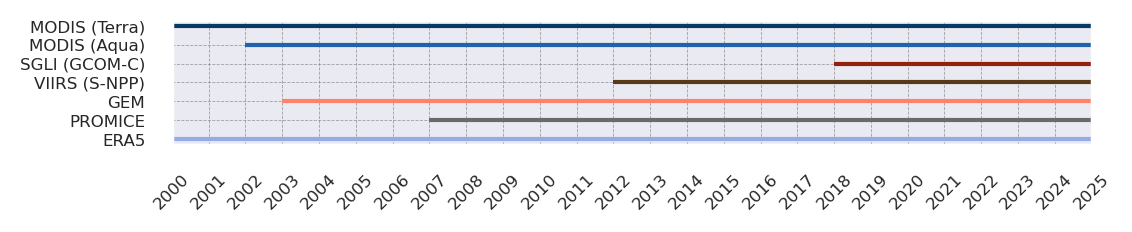

In [86]:

satellites = {
    "MODIS (Terra)": (datetime(2000, 2, 24), datetime(2025, 12, 31), "#083962"),
    "MODIS (Aqua)": (datetime(2002, 7, 4), datetime(2025, 12, 31), "#2062ac"),
    "SGLI (GCOM-C)": (datetime(2018, 1, 1), datetime(2025, 12, 31), "#942010"),
    "VIIRS (S-NPP)": (datetime(2012, 1, 19), datetime(2025, 12, 31), "#5a3918"),
    "GEM" : (datetime(2003, 8, 5), datetime(2025, 1, 1), "#ff836a"),
    "PROMICE": (datetime(2007, 8, 23), datetime(2025, 1, 10), "#6a6a6a"),
    "ERA5": (datetime(2000, 1, 1), datetime(2025, 12, 31), "#94ace6")
}


plt.figure(figsize=(6, 1.5), dpi=200)

# Manually set y positions for tight spacing
y_positions = [0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.9]  # Adjust as needed

for i, (satellite, (start, end, color)) in enumerate(satellites.items()):
    plt.hlines(
        y=y_positions[i], 
        xmin=start.year, xmax=(end.year+1),
        color=color,
        )

plt.yticks(y_positions, list(satellites.keys()), fontsize=6)
plt.xlim(2000, 2025)
plt.xticks(range(2000, 2026, 1), fontsize=6, rotation=45)
plt.gca().invert_yaxis()
plt.grid(linestyle='--', alpha=0.7, color='gray', linewidth=0.3)


plt.tight_layout()
plt.savefig('data_timeline_lines.png', format='PNG', dpi=200, bbox_inches='tight')
plt.show()

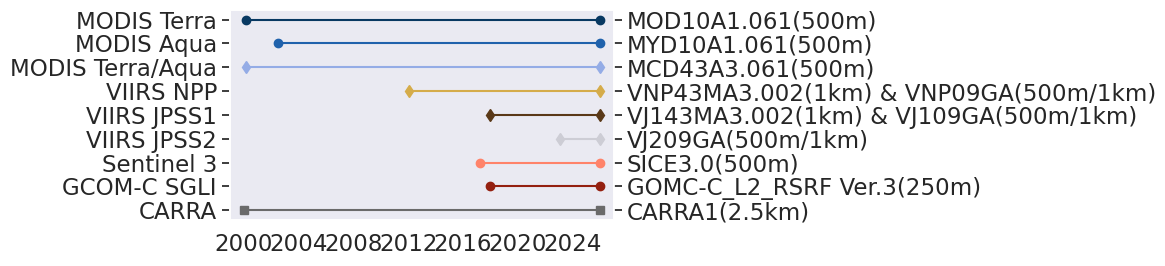

In [10]:
'''
Plot timeline of satellite missions and data sources used for the HSA500m dataset, including:
- MODIS Terra(MOD10A1): 2000-02-24 to 2025-12-31 (MOD10A1.061)
- MODIS Aqua(MYD10A1): 2002-07-04 to 2025-12-31 (MYD10A1.061)
- MODIS Terra/Aqua(MCD43A3): 2000-02-24 to 2025-12-31 (MCD43A3.061)

- VIIRS/NPP(VNP43MA3): 2012-01-17 to 2025-12-31 (VNP43MA3.002)
- VIIRS/JPSS1(VJ143MA3): 2018-01-01 to 2025-12-31 (VJ143MA3.002)

- Sentinel3(SICE): 2017-04-01 to 2025-12-31 (SICE3.0)

- GCOM-C/SGLI(L2.LAND.RSRF): 2018-01-01 to 2025-12-31 (GCOM-C_SGLI_L2_RSRF Ver.3)

- CARRA: 2000-01-01 to 2025-12-31 (CARRA1)

Shunan Feng (shunan.feng@envs.au.dk)
'''

#%%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(font_scale=1.5, style="dark")
#%%
# define satellite mission timelines and versions used for HSA500m dataset
missions = {
    "MODIS Terra": ("2000-02-24", "2025-12-31", "MOD10A1.061(500m)"),
    "MODIS Aqua": ("2002-07-04", "2025-12-31", "MYD10A1.061(500m)"),
    "MODIS Terra/Aqua": ("2000-02-24", "2025-12-31", "MCD43A3.061(500m)"),

    "VIIRS NPP": ("2012-01-17", "2025-12-31", "VNP43MA3.002(1km) & VNP09GA(500m/1km)"),
    "VIIRS JPSS1": ("2018-01-01", "2025-12-31", "VJ143MA3.002(1km) & VJ109GA(500m/1km)"),
    "VIIRS JPSS2": ("2023-02-10", "2025-12-31", "VJ209GA(500m/1km)"),

    "Sentinel 3": ("2017-04-01", "2025-12-31", "SICE3.0(500m)"),

    "GCOM-C SGLI": ("2018-01-01", "2025-12-31", "GOMC-C_L2_RSRF Ver.3(250m)"),

    "CARRA": ("2000-01-01", "2025-12-31", "CARRA1(2.5km)"),
}
df = pd.DataFrame(missions).T.reset_index()
df.columns = ["Mission", "Start", "End", "Version"]
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])

# define color and marker for sensors
sensor_colors = {
    # Blastoise palette for MODIS, VIIRS
    "MODIS Terra": ("#083962", "o"),
    "MODIS Aqua": ("#2062ac", "o"),
    "MODIS Terra/Aqua": ("#94ace6", "d"),
    "VIIRS JPSS1": ("#5a3918", "d"),
    "VIIRS NPP": ("#d5ac4a", "d"),
    "VIIRS JPSS2": ("#cdcdd5", "d"),
    # Charmeleon palette for Sentinel 3, GCOM-C, CARRA
    "Sentinel 3": ("#ff836a", "o"), 
    "GCOM-C SGLI": ("#942010", "o"), 
    "CARRA": ("#6a6a6a", "s"), 
}
#%%
fig, ax = plt.subplots(figsize=(12, 3))
# plot rows from top to bottom in the figure by the order in the dataframe
    
for i, row in df.iterrows():
    color, marker = sensor_colors.get(row["Mission"], ("black", "."))
    ax.plot([row["Start"], row["End"]], [i, i], marker=marker, label=row["Mission"], color=color)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Mission"])
# Make the dataframe order map from top to bottom in the figure.
ax.invert_yaxis()

# Add product version labels on a right-side y-axis aligned with mission rows.
ax_right = ax.twinx()
ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(range(len(df)))
ax_right.set_yticklabels(df["Version"])

ax.set_xlim(pd.to_datetime("1999-01-01"), pd.to_datetime("2027-01-01"))

plt.tight_layout()
#plt.savefig("/data/shunan/github/Harmonized-Albedo-for-the-Greenland-Ice-Sheet-at-500m/print/satellite_mission_timelines.pdf", bbox_inches="tight", dpi=300)
#plt.savefig("/data/shunan/github/Harmonized-Albedo-for-the-Greenland-Ice-Sheet-at-500m/print/satellite_mission_timelines.png", bbox_inches="tight", dpi=300)
# %%